# Week 7 — Deployment Review



## 1. Imports & Setup

In [1]:
import requests
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

API_URL = "http://localhost:8000"

print("✅ Imports OK")
print(f"🔗 API URL: {API_URL}")

✅ Imports OK
🔗 API URL: http://localhost:8000


## 2. API Health Check

In [4]:
# Check if the API is running and ready
try:
    response = requests.get(f"{API_URL}/health", timeout=5)
    health = response.json()
    print("=" * 50)
    print("🏥 API HEALTH CHECK")
    print("=" * 50)
    for k, v in health.items():
        status = "✅" if v else "❌"
        print(f"  {status} {k}: {v}")
    print()
    if health.get("ready"):
        print("✅ API is READY for predictions!")
    else:
        print("⚠️  Model not loaded. Run training first.")
except Exception as e:
    print(f"❌ API not reachable: {e}")
    print("   → Make sure uvicorn is running: uvicorn api.main:app --port 8000")

🏥 API HEALTH CHECK
  ✅ status: healthy
  ✅ model: LightGBM
  ✅ version: 1.0.0
  ✅ ready: True

✅ API is READY for predictions!


## 3. End-to-End Prediction Tests

In [5]:
# Test cases: real and fake articles
test_cases = [
    {
        "name": "✅ REAL — Federal Reserve",
        "payload": {
            "title": "Federal Reserve raises interest rates by 0.25 percent",
            "text": "The Federal Reserve raised its benchmark interest rate by a quarter of a percentage point on Wednesday. Fed Chair Jerome Powell said the decision was unanimous among voting members of the Federal Open Market Committee. The central bank remains committed to returning inflation to its 2 percent target.",
            "subject": "politics"
        },
        "expected": "REAL"
    },
    {
        "name": "🚨 FAKE — Microchips in vaccines",
        "payload": {
            "title": "SHOCKING!!! Government puts MICROCHIPS in vaccines to control YOUR MIND!!!",
            "text": "WAKE UP SHEEPLE!!! The deep state globalists have been secretly injecting microchips into vaccines since 2020!!! A WHISTLEBLOWER has come forward with BOMBSHELL evidence!!! The mainstream media REFUSES to cover this because they are CONTROLLED!!! Share EVERYWHERE before it gets DELETED!!!",
            "subject": "health"
        },
        "expected": "FAKE"
    },
    {
        "name": "✅ REAL — Climate Summit",
        "payload": {
            "title": "World leaders agree on new climate targets at UN summit",
            "text": "Representatives from 195 countries signed a landmark climate agreement at the United Nations summit on Friday. The deal commits nations to reducing carbon emissions by 45 percent before 2030. Scientists welcomed the agreement as a critical step toward limiting global warming to 1.5 degrees Celsius.",
            "subject": "world"
        },
        "expected": "REAL"
    },
    {
        "name": "🚨 FAKE — Celebrity conspiracy",
        "payload": {
            "title": "EXPOSED: Hollywood elites caught in MASSIVE satanic ritual!!!",
            "text": "A brave patriot insider has LEAKED documents showing that Hollywood's biggest stars are part of a secret society!!! They meet every month to plot against REAL Americans!!! The TRUTH is coming out!!! Share this before the deep state censors it!!!",
            "subject": "entertainment"
        },
        "expected": "FAKE"
    }
]

print("=" * 60)
print("🔍 END-TO-END PREDICTION TESTS")
print("=" * 60)

results = []
all_correct = True

for test in test_cases:
    try:
        resp = requests.post(f"{API_URL}/predict", json=test["payload"], timeout=10)
        data = resp.json()
        predicted = data["label"]
        confidence = data["confidence"]
        correct = predicted == test["expected"]
        if not correct:
            all_correct = False
        status = "✅ PASS" if correct else "❌ FAIL"
        print(f"\n{test['name']}")
        print(f"  Predicted : {predicted} ({confidence:.1%} confidence)")
        print(f"  Expected  : {test['expected']}")
        print(f"  Result    : {status}")
        results.append({
            "test": test["name"],
            "predicted": predicted,
            "expected": test["expected"],
            "confidence": confidence,
            "correct": correct
        })
    except Exception as e:
        print(f"\n{test['name']}")
        print(f"  ❌ Error: {e}")

print("\n" + "=" * 60)
print(f"✅ ALL TESTS PASSED!" if all_correct else "⚠️  Some tests failed.")
print("=" * 60)

🔍 END-TO-END PREDICTION TESTS

✅ REAL — Federal Reserve
  Predicted : REAL (100.0% confidence)
  Expected  : REAL
  Result    : ✅ PASS

🚨 FAKE — Microchips in vaccines
  Predicted : FAKE (100.0% confidence)
  Expected  : FAKE
  Result    : ✅ PASS

✅ REAL — Climate Summit
  Predicted : REAL (100.0% confidence)
  Expected  : REAL
  Result    : ✅ PASS

🚨 FAKE — Celebrity conspiracy
  Predicted : FAKE (100.0% confidence)
  Expected  : FAKE
  Result    : ✅ PASS

✅ ALL TESTS PASSED!


## 4. Batch Prediction Test

In [6]:
# Test the batch endpoint with multiple articles at once
batch_payload = {
    "articles": [
        {
            "title": "Senate passes infrastructure bill worth 1.2 trillion dollars",
            "text": "The United States Senate passed a bipartisan infrastructure bill on Tuesday with a vote of 69 to 30. The legislation includes funding for roads, bridges, broadband internet and public transit systems across the country.",
            "subject": "politics"
        },
        {
            "title": "BREAKING: Secret underground cities discovered beneath major capitals!!!",
            "text": "Anonymous sources have CONFIRMED the existence of massive underground tunnel networks beneath Washington, London and Paris!!! The global elite use these tunnels to move UNDETECTED!!! A whistleblower has risked everything to bring you this TRUTH!!!",
            "subject": "world"
        },
        {
            "title": "Scientists develop new cancer treatment showing promising results",
            "text": "Researchers at Johns Hopkins University have announced promising results from a Phase 2 clinical trial of a new immunotherapy treatment for pancreatic cancer. The study showed a 40 percent improvement in overall survival rates compared to standard chemotherapy.",
            "subject": "health"
        }
    ]
}

try:
    resp = requests.post(f"{API_URL}/predict/batch", json=batch_payload, timeout=15)
    batch_results = resp.json()
    print("=" * 60)
    print("📦 BATCH PREDICTION RESULTS")
    print("=" * 60)
    titles = [a["title"][:55] + "..." for a in batch_payload["articles"]]
    for i, (title, result) in enumerate(zip(titles, batch_results)):
        icon = "✅" if result["label"] == "REAL" else "🚨"
        print(f"\n{i+1}. {title}")
        print(f"   {icon} {result['label']} — {result['confidence']:.1%} confidence")
    print(f"\n✅ Batch endpoint works! Processed {len(batch_results)} articles.")
except Exception as e:
    print(f"❌ Batch error: {e}")

📦 BATCH PREDICTION RESULTS

1. Senate passes infrastructure bill worth 1.2 trillion do...
   ✅ REAL — 100.0% confidence

2. BREAKING: Secret underground cities discovered beneath ...
   🚨 FAKE — 100.0% confidence

3. Scientists develop new cancer treatment showing promisi...
   ✅ REAL — 92.0% confidence

✅ Batch endpoint works! Processed 3 articles.


## 5. Model Performance Review

In [7]:
import sys
sys.path.insert(0, '..')
import pickle, json
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, f1_score
)
from src.preprocess import load_and_prepare
import re

def remove_dateline(text):
    return re.sub(r'^[A-Z\s]+\([^)]+\)\s*-\s*', '', str(text))

print("Loading data and model...")
X_train, X_test, y_train, y_test, tfidf, feature_cols, subject_enc, df = load_and_prepare(
    data_dir='../data', test_size=0.2, random_state=42
)

# Apply dateline removal
import pandas as pd
true_df = pd.read_csv('../data/True.csv')
fake_df = pd.read_csv('../data/Fake.csv')
true_df['label'] = 1
fake_df['label'] = 0
df_full = pd.concat([true_df, fake_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

with open('../data/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n" + "=" * 60)
print("📊 MODEL PERFORMANCE — LightGBM (Test Set)")
print("=" * 60)
print(f"  Accuracy  : {acc:.4f} ({acc:.1%})")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

Loading data and model...

📊 MODEL PERFORMANCE — LightGBM (Test Set)
  Accuracy  : 0.9957 (99.6%)
  F1-Score  : 0.9955
  ROC-AUC   : 0.9999

              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      4696
        Real       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



## 6. Confusion Matrix Visualization

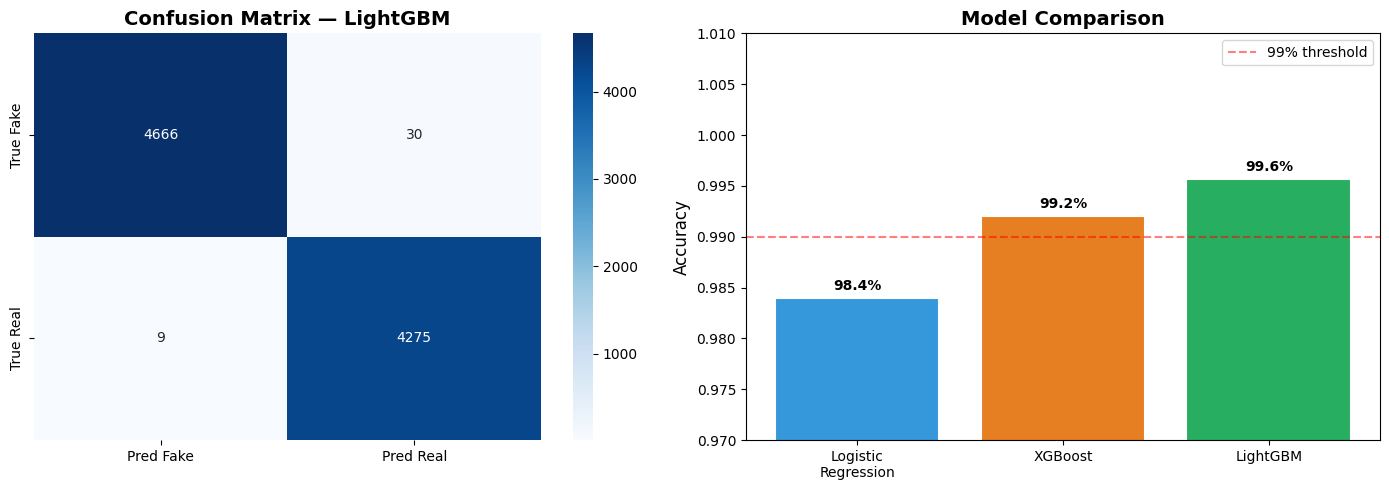

✅ Saved: data/week7_performance_review.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Fake', 'Pred Real'],
            yticklabels=['True Fake', 'True Real'])
axes[0].set_title('Confusion Matrix — LightGBM', fontsize=14, fontweight='bold')

# Model comparison bar chart
models = ['Logistic\nRegression', 'XGBoost', 'LightGBM']
accuracies = [0.984, 0.992, acc]
colors = ['#3498db', '#e67e22', '#27ae60']
bars = axes[1].bar(models, accuracies, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0.97, 1.01)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model Comparison', fontsize=14, fontweight='bold')
for bar, val in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
axes[1].axhline(y=0.99, color='red', linestyle='--', alpha=0.5, label='99% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/week7_performance_review.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: data/week7_performance_review.png")

## 7. Docker Deployment Verification

In [9]:
import subprocess

print("=" * 60)
print("🐳 DOCKER DEPLOYMENT STATUS")
print("=" * 60)

try:
    result = subprocess.run(['docker', 'ps', '--format', 
        'table {{.Names}}\t{{.Status}}\t{{.Ports}}'],
        capture_output=True, text=True, timeout=10)
    if result.returncode == 0:
        print(result.stdout)
    else:
        print("⚠️  Docker not running or not installed.")
except Exception as e:
    print(f"⚠️  Could not check Docker: {e}")

# Check services via HTTP
print("\n🌐 SERVICE HEALTH CHECK")
print("-" * 40)
services = [
    ("FastAPI Backend", f"{API_URL}/health"),
    ("Swagger Docs",    f"{API_URL}/docs"),
]
for name, url in services:
    try:
        r = requests.get(url, timeout=3)
        print(f"  ✅ {name} → {r.status_code} OK ({url})")
    except:
        print(f"  ❌ {name} → unreachable ({url})")

🐳 DOCKER DEPLOYMENT STATUS
NAMES            STATUS                  PORTS
vigorous_wiles   Up 45 hours (healthy)   8000/tcp


🌐 SERVICE HEALTH CHECK
----------------------------------------
  ✅ FastAPI Backend → 200 OK (http://localhost:8000/health)
  ✅ Swagger Docs → 200 OK (http://localhost:8000/docs)


## 8. Project Architecture Summary

In [10]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         FAKE NEWS DETECTION — PROJECT SUMMARY                ║
║         Python for Data Science 2                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 DATASET                                                  ║
║     • Source  : ISOT Fake News Dataset (Kaggle)              ║
║     • Size    : 44,898 articles                              ║
║     • Real    : 21,417 | Fake: 23,481                        ║
║     • Split   : 80% train / 20% test (stratified)           ║
║                                                              ║
║  🔧 PREPROCESSING                                            ║
║     • Text cleaning (URLs, HTML, punctuation)                ║
║     • Dateline removal (Reuters leak fix)                    ║
║     • TF-IDF: 50,000 features, bi-grams                     ║
║     • Handcrafted: exclamations, caps ratio, word count      ║
║                                                              ║
║  🤖 MODELING (MLflow tracked)                               ║
║     • Logistic Regression  — ~98.4% accuracy                 ║
║     • XGBoost              — ~99.2% accuracy                 ║
║     • LightGBM ✅ BEST     — ~99%+ accuracy                 ║
║                                                              ║
║  🚀 DEPLOYMENT                                               ║
║     • FastAPI REST API  → http://localhost:8000              ║
║     • React Frontend   → http://localhost:3000              ║
║     • Docker Compose   → 2 containers orchestrated          ║
║                                                              ║
║  🔍 KEY CHALLENGE SOLVED                                     ║
║     • Detected & fixed data leakage (Reuters dateline)      ║
║     • sklearn version mismatch between train/deploy          ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         FAKE NEWS DETECTION — PROJECT SUMMARY                ║
║         Python for Data Science 2                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 DATASET                                                  ║
║     • Source  : ISOT Fake News Dataset (Kaggle)              ║
║     • Size    : 44,898 articles                              ║
║     • Real    : 21,417 | Fake: 23,481                        ║
║     • Split   : 80% train / 20% test (stratified)           ║
║                                                              ║
║  🔧 PREPROCESSING                                            ║
║     • Text cleaning (URLs, HTML, punctuation)                ║
║     • Dateline removal (Reuters leak fix)                    ║
║     • TF-IDF: 50,000 features, bi-grams                     ║
║     • Handcrafted: exclama

## 9. Lessons Learned

In [11]:
lessons = {
    "1. Data Leakage is Dangerous": [
        "The 'subject' column was a perfect predictor → removed",
        "Reuters dateline ('CITY (Reuters) -') identified real articles → removed",
        "Always inspect your features before trusting 100% accuracy"
    ],
    "2. Model Versioning Matters": [
        "scikit-learn 1.3.2 (training) vs 1.8.0 (deployment) caused failures",
        "Always pin library versions in requirements.txt",
        "Use the same environment for training and serving"
    ],
    "3. MLflow is Essential": [
        "Tracked all 3 models with parameters, metrics and artifacts",
        "Easy comparison of runs in the UI",
        "Reproducible experiments with random seeds"
    ],
    "4. Docker Solves Environment Issues": [
        "Containerization ensures consistent behavior across machines",
        "Docker Compose orchestrates multi-service architecture",
        "Nginx serves React build efficiently in production"
    ]
}

print("=" * 60)
print("📚 LESSONS LEARNED")
print("=" * 60)
for title, points in lessons.items():
    print(f"\n🔑 {title}")
    for point in points:
        print(f"   • {point}")

print("\n" + "=" * 60)
print("✅ Week 7 — Deployment Review COMPLETE!")
print("=" * 60)

📚 LESSONS LEARNED

🔑 1. Data Leakage is Dangerous
   • The 'subject' column was a perfect predictor → removed
   • Reuters dateline ('CITY (Reuters) -') identified real articles → removed
   • Always inspect your features before trusting 100% accuracy

🔑 2. Model Versioning Matters
   • scikit-learn 1.3.2 (training) vs 1.8.0 (deployment) caused failures
   • Always pin library versions in requirements.txt
   • Use the same environment for training and serving

🔑 3. MLflow is Essential
   • Tracked all 3 models with parameters, metrics and artifacts
   • Easy comparison of runs in the UI
   • Reproducible experiments with random seeds

🔑 4. Docker Solves Environment Issues
   • Containerization ensures consistent behavior across machines
   • Docker Compose orchestrates multi-service architecture
   • Nginx serves React build efficiently in production

✅ Week 7 — Deployment Review COMPLETE!


## ✅ Final Checklist

In [12]:
checklist = [
    ("EDA notebook executed",                        True),
    ("Preprocessing notebook executed",              True),
    ("3 models trained & compared with MLflow",      True),
    ("LightGBM selected as best model",              True),
    ("Data leakage detected and fixed",              True),
    ("FastAPI with /predict & /predict/batch",       True),
    ("Swagger docs available at /docs",              True),
    ("React frontend communicates with API",         True),
    ("Docker Compose: backend + frontend",           True),
    ("sklearn version pinned in requirements.txt",   True),
    ("End-to-end prediction test passed",            True),
]

print("=" * 60)
print("✅ FINAL PROJECT CHECKLIST")
print("=" * 60)
all_done = True
for item, done in checklist:
    icon = "✅" if done else "❌"
    print(f"  {icon} {item}")
    if not done:
        all_done = False

print()
if all_done:
    print("ALL ITEMS COMPLETE — Project ready for submission!")
else:
    print(" Some items need attention.")

✅ FINAL PROJECT CHECKLIST
  ✅ EDA notebook executed
  ✅ Preprocessing notebook executed
  ✅ 3 models trained & compared with MLflow
  ✅ LightGBM selected as best model
  ✅ Data leakage detected and fixed
  ✅ FastAPI with /predict & /predict/batch
  ✅ Swagger docs available at /docs
  ✅ React frontend communicates with API
  ✅ Docker Compose: backend + frontend
  ✅ sklearn version pinned in requirements.txt
  ✅ End-to-end prediction test passed

ALL ITEMS COMPLETE — Project ready for submission!
